In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('netflix.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [9]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

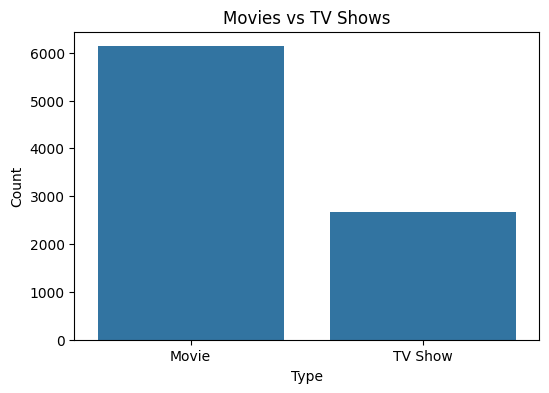

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

In [11]:
### Business Insight Netflix's library is dominated by Movies, indicating a strong focus on movie distribution compared to TV Shows.

In [12]:
# Top 10 Countries by Content


In [13]:
top_countries=(
    df['country']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)
top_countries

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

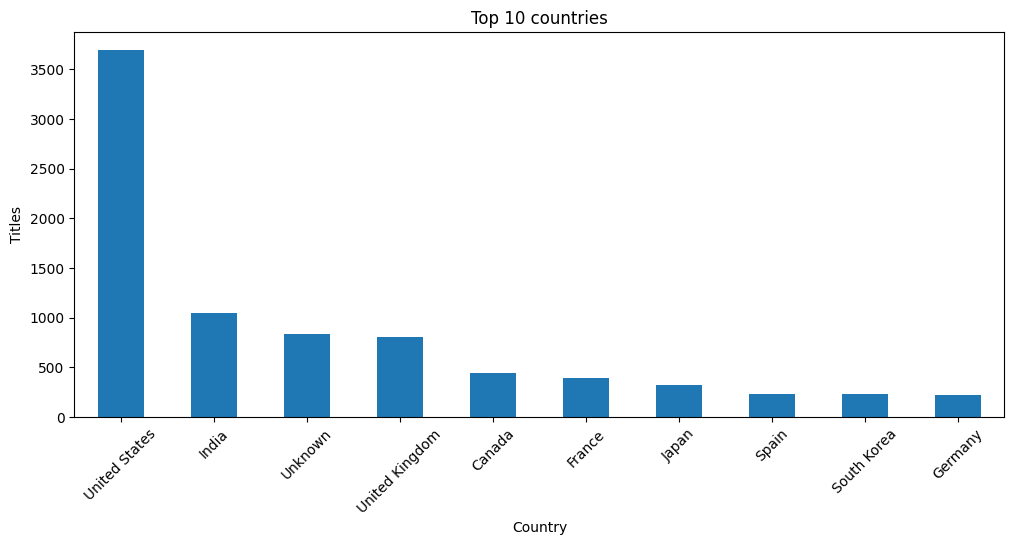

In [14]:
plt.figure(figsize=(12,5))
top_countries.plot(kind='bar')
plt.title('Top 10 countries')
plt.xlabel('Country')
plt.ylabel('Titles')
plt.xticks(rotation=45)
plt.show()

In [15]:
## The United States contributes the highest number of Netflix titles, followed by India and the United Kingdom. This highlights Netflix's strong presence in major entertainment markets.

In [17]:
# Ratings Distribution

In [18]:
df['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

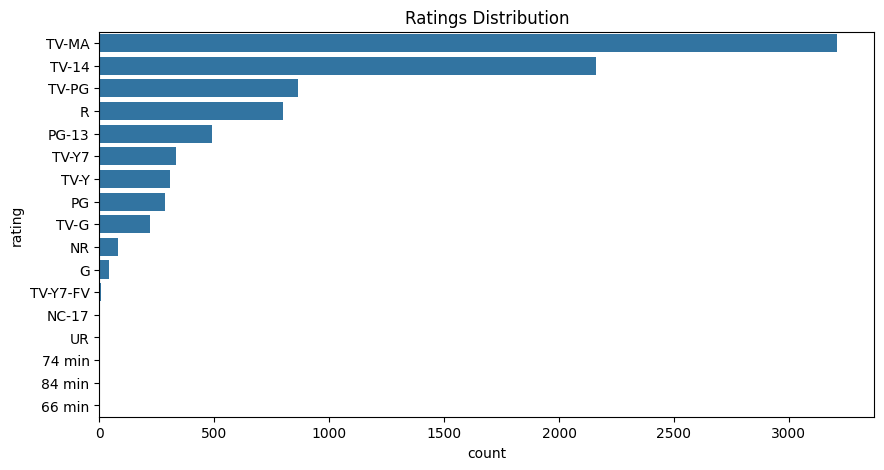

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y ='rating',
    order=df['rating'].value_counts().index
)
plt.title("Ratings Distribution")
plt.show()

In [20]:
## TV-MA and TV-14 dominate Netflix's catalog, indicating a strong focus on mature and teen audiences.

In [21]:
# Release Year Analysis

In [22]:
release = df['release_year'].value_counts().sort_index()

release.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

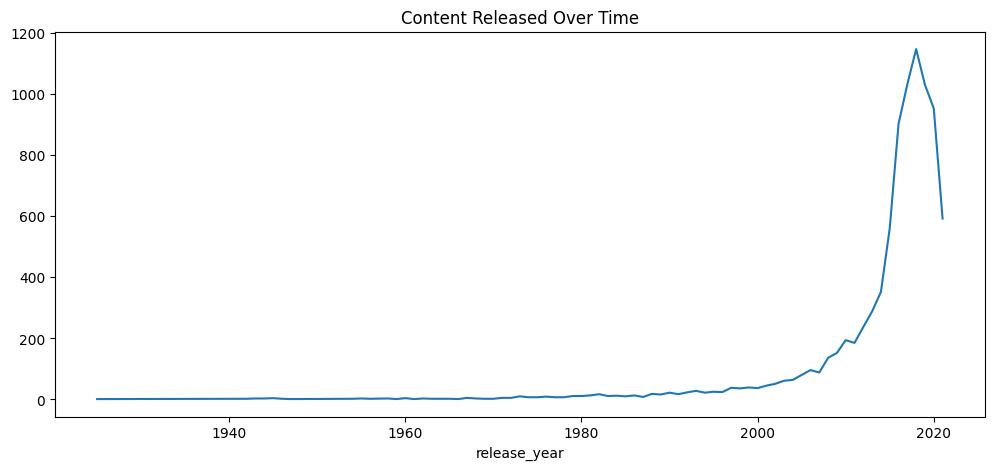

In [23]:
plt.figure(figsize=(12,5))

release.plot()

plt.title("Content Released Over Time")

plt.show()

In [24]:
#Genre Analysis

In [25]:
genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

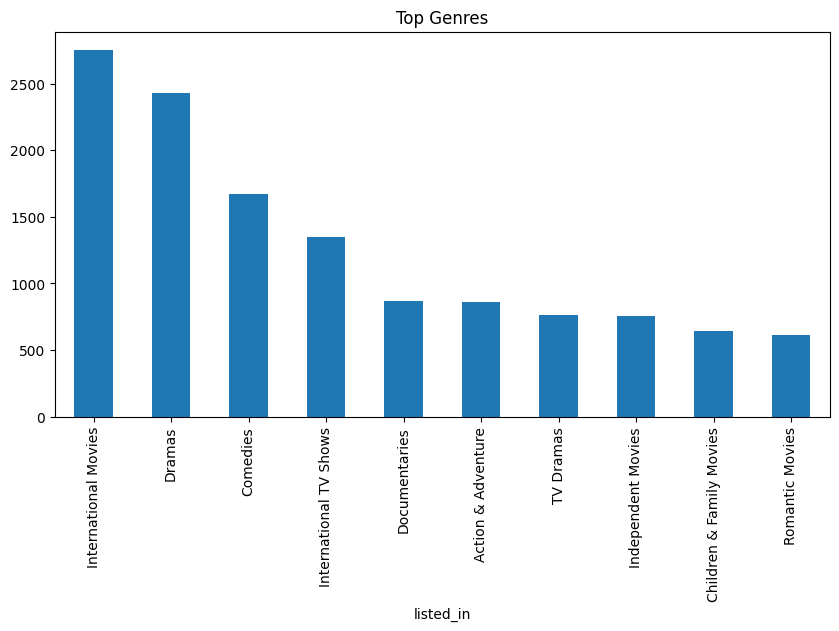

In [26]:
plt.figure(figsize=(10,5))

genres.plot(kind='bar')

plt.title("Top Genres")

plt.show()

In [34]:
# ## Business Insight

# International Movies and Dramas are among the most popular genres available on Netflix.

In [40]:
# Top Directors


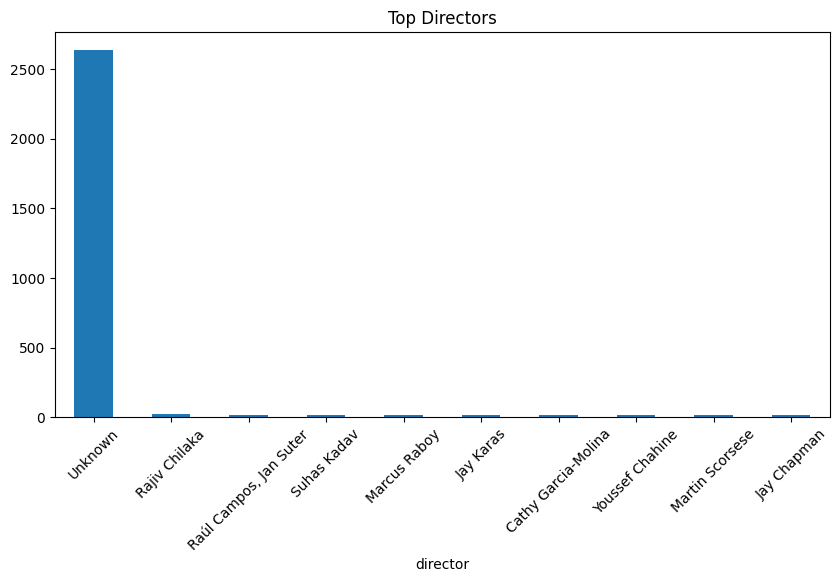

In [39]:
top_directors = (
    df['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_directors.plot(kind='bar')

plt.title("Top Directors")

plt.xticks(rotation=45)

plt.show()

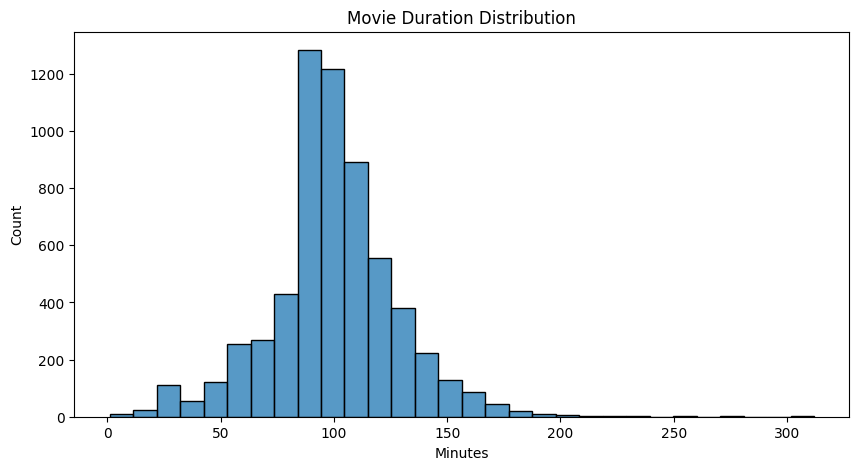

Average Movie Duration : 99.53 Minutes


In [38]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_num'] = (
    movies['duration']
    .str.extract(r'(\d+)')
    .astype(int)
)

plt.figure(figsize=(10,5))

sns.histplot(
    movies['duration_num'],
    bins=30
)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Count")

plt.show()

print("Average Movie Duration :",
      round(movies['duration_num'].mean(),2),"Minutes")

In [44]:
# Top 10 Actors

In [45]:
actors = (
    df['cast']
    .str.split(', ')
    .explode()
)

actors = actors[actors != 'Unknown']

top_actors = actors.value_counts().head(10)

top_actors

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

In [47]:
movies['duration_num'].describe()

count    6131.000000
mean       99.528951
std        28.367576
min         1.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64

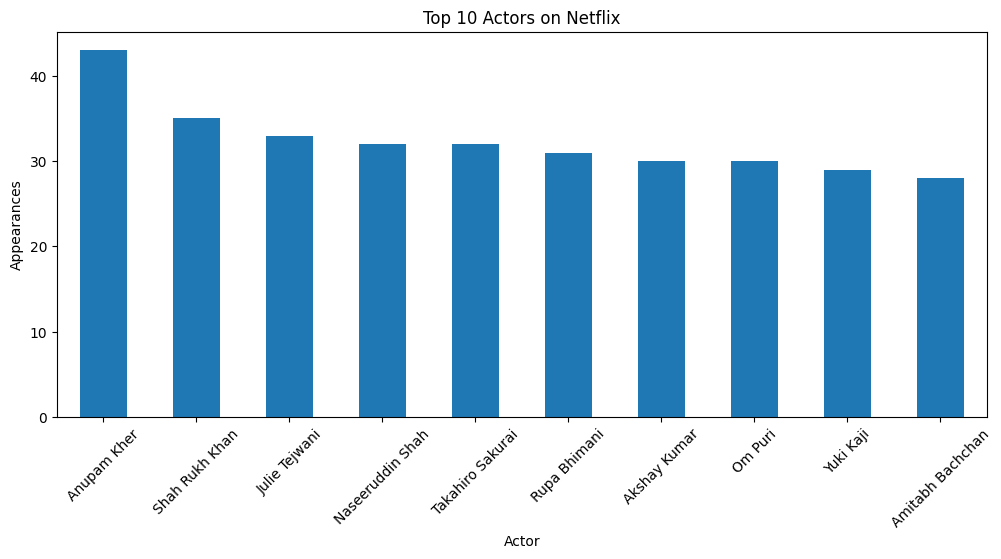

In [46]:
plt.figure(figsize=(12,5))

top_actors.plot(kind='bar')

plt.title('Top 10 Actors on Netflix')

plt.xlabel('Actor')

plt.ylabel('Appearances')

plt.xticks(rotation=45)

plt.show()

In [48]:
## Business Insight

# Several actors appear repeatedly in Netflix productions, suggesting long-term partnerships and audience preferences.

In [49]:
# Correalation

In [50]:
movies['duration_num'].describe()


count    6131.000000
mean       99.528951
std        28.367576
min         1.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64

In [52]:
# Executive Summary

## Key Findings

- Movies dominate Netflixs content library.
- The United States contributes the highest number of titles.
- TV-MA is the most common rating.
- Netflix experienced significant growth after 2015.
- International Movies are among the most popular genres.
- Most Netflix movies range between 80–120 minutes.
- Certain directors and actors have strong representation on the platform.

SyntaxError: invalid character '–' (U+2013) (669926112.py, line 10)

In [53]:
import os

print(os.getcwd())

F:\DataScience\proj\Netflix_SQL_Project-main\Netflix_SQL_Project-main
